In [25]:
from copy import deepcopy

import matplotlib.pyplot as plt
from matplotlib.colors import CenteredNorm, LogNorm

from mejiro.synthetic_image import SyntheticImage
from mejiro.exposure import Exposure
from mejiro.instruments.roman import Roman
from mejiro.engines.stpsf_engine import STPSFEngine
from mejiro.lensed_supernova import LensedSupernova
from mejiro.utils import util
from mejiro.style import set_aas_style
set_aas_style()

In [26]:
lens_population = util.unpickle('sn_lens_population.pkl')

In [27]:
idx = 33
sample = lens_population[idx]

In [28]:
sn = LensedSupernova.from_slsim(sample, name=f'sn_{str(idx).zfill(3)}')

In [29]:
roman = Roman()
kwargs_psf = STPSFEngine.get_roman_psf_kwargs('F129', 1, (2044, 2044), 5, 101, True, '/data/bwedig/mejiro/cached_psfs')

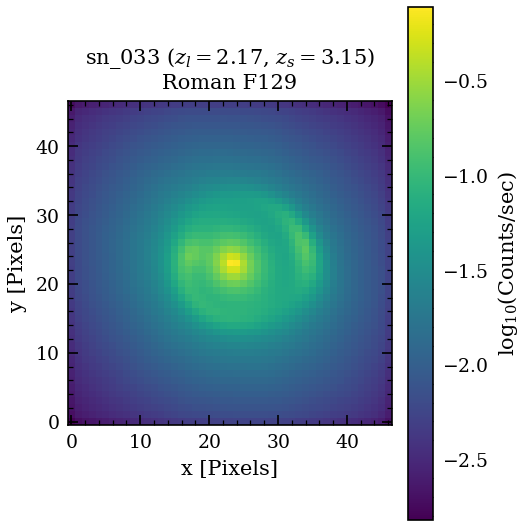

In [30]:
synth = SyntheticImage(sn, roman, 'F129', pieces=True, kwargs_psf=kwargs_psf)
synth.plot()

Error occurred while processing sample 3: kwargs_variability_model requires information about band F106
Error occurred while processing sample 12: kwargs_variability_model requires information about band F106
Error occurred while processing sample 15: kwargs_variability_model requires information about band F106
Error occurred while processing sample 18: kwargs_variability_model requires information about band F106
Error occurred while processing sample 35: kwargs_variability_model requires information about band F106
Error occurred while processing sample 48: kwargs_variability_model requires information about band F106
Error occurred while processing sample 58: kwargs_variability_model requires information about band F106
Error occurred while processing sample 59: kwargs_variability_model requires information about band F106
Error occurred while processing sample 66: kwargs_variability_model requires information about band F106
Error occurred while processing sample 67: kwargs_variab

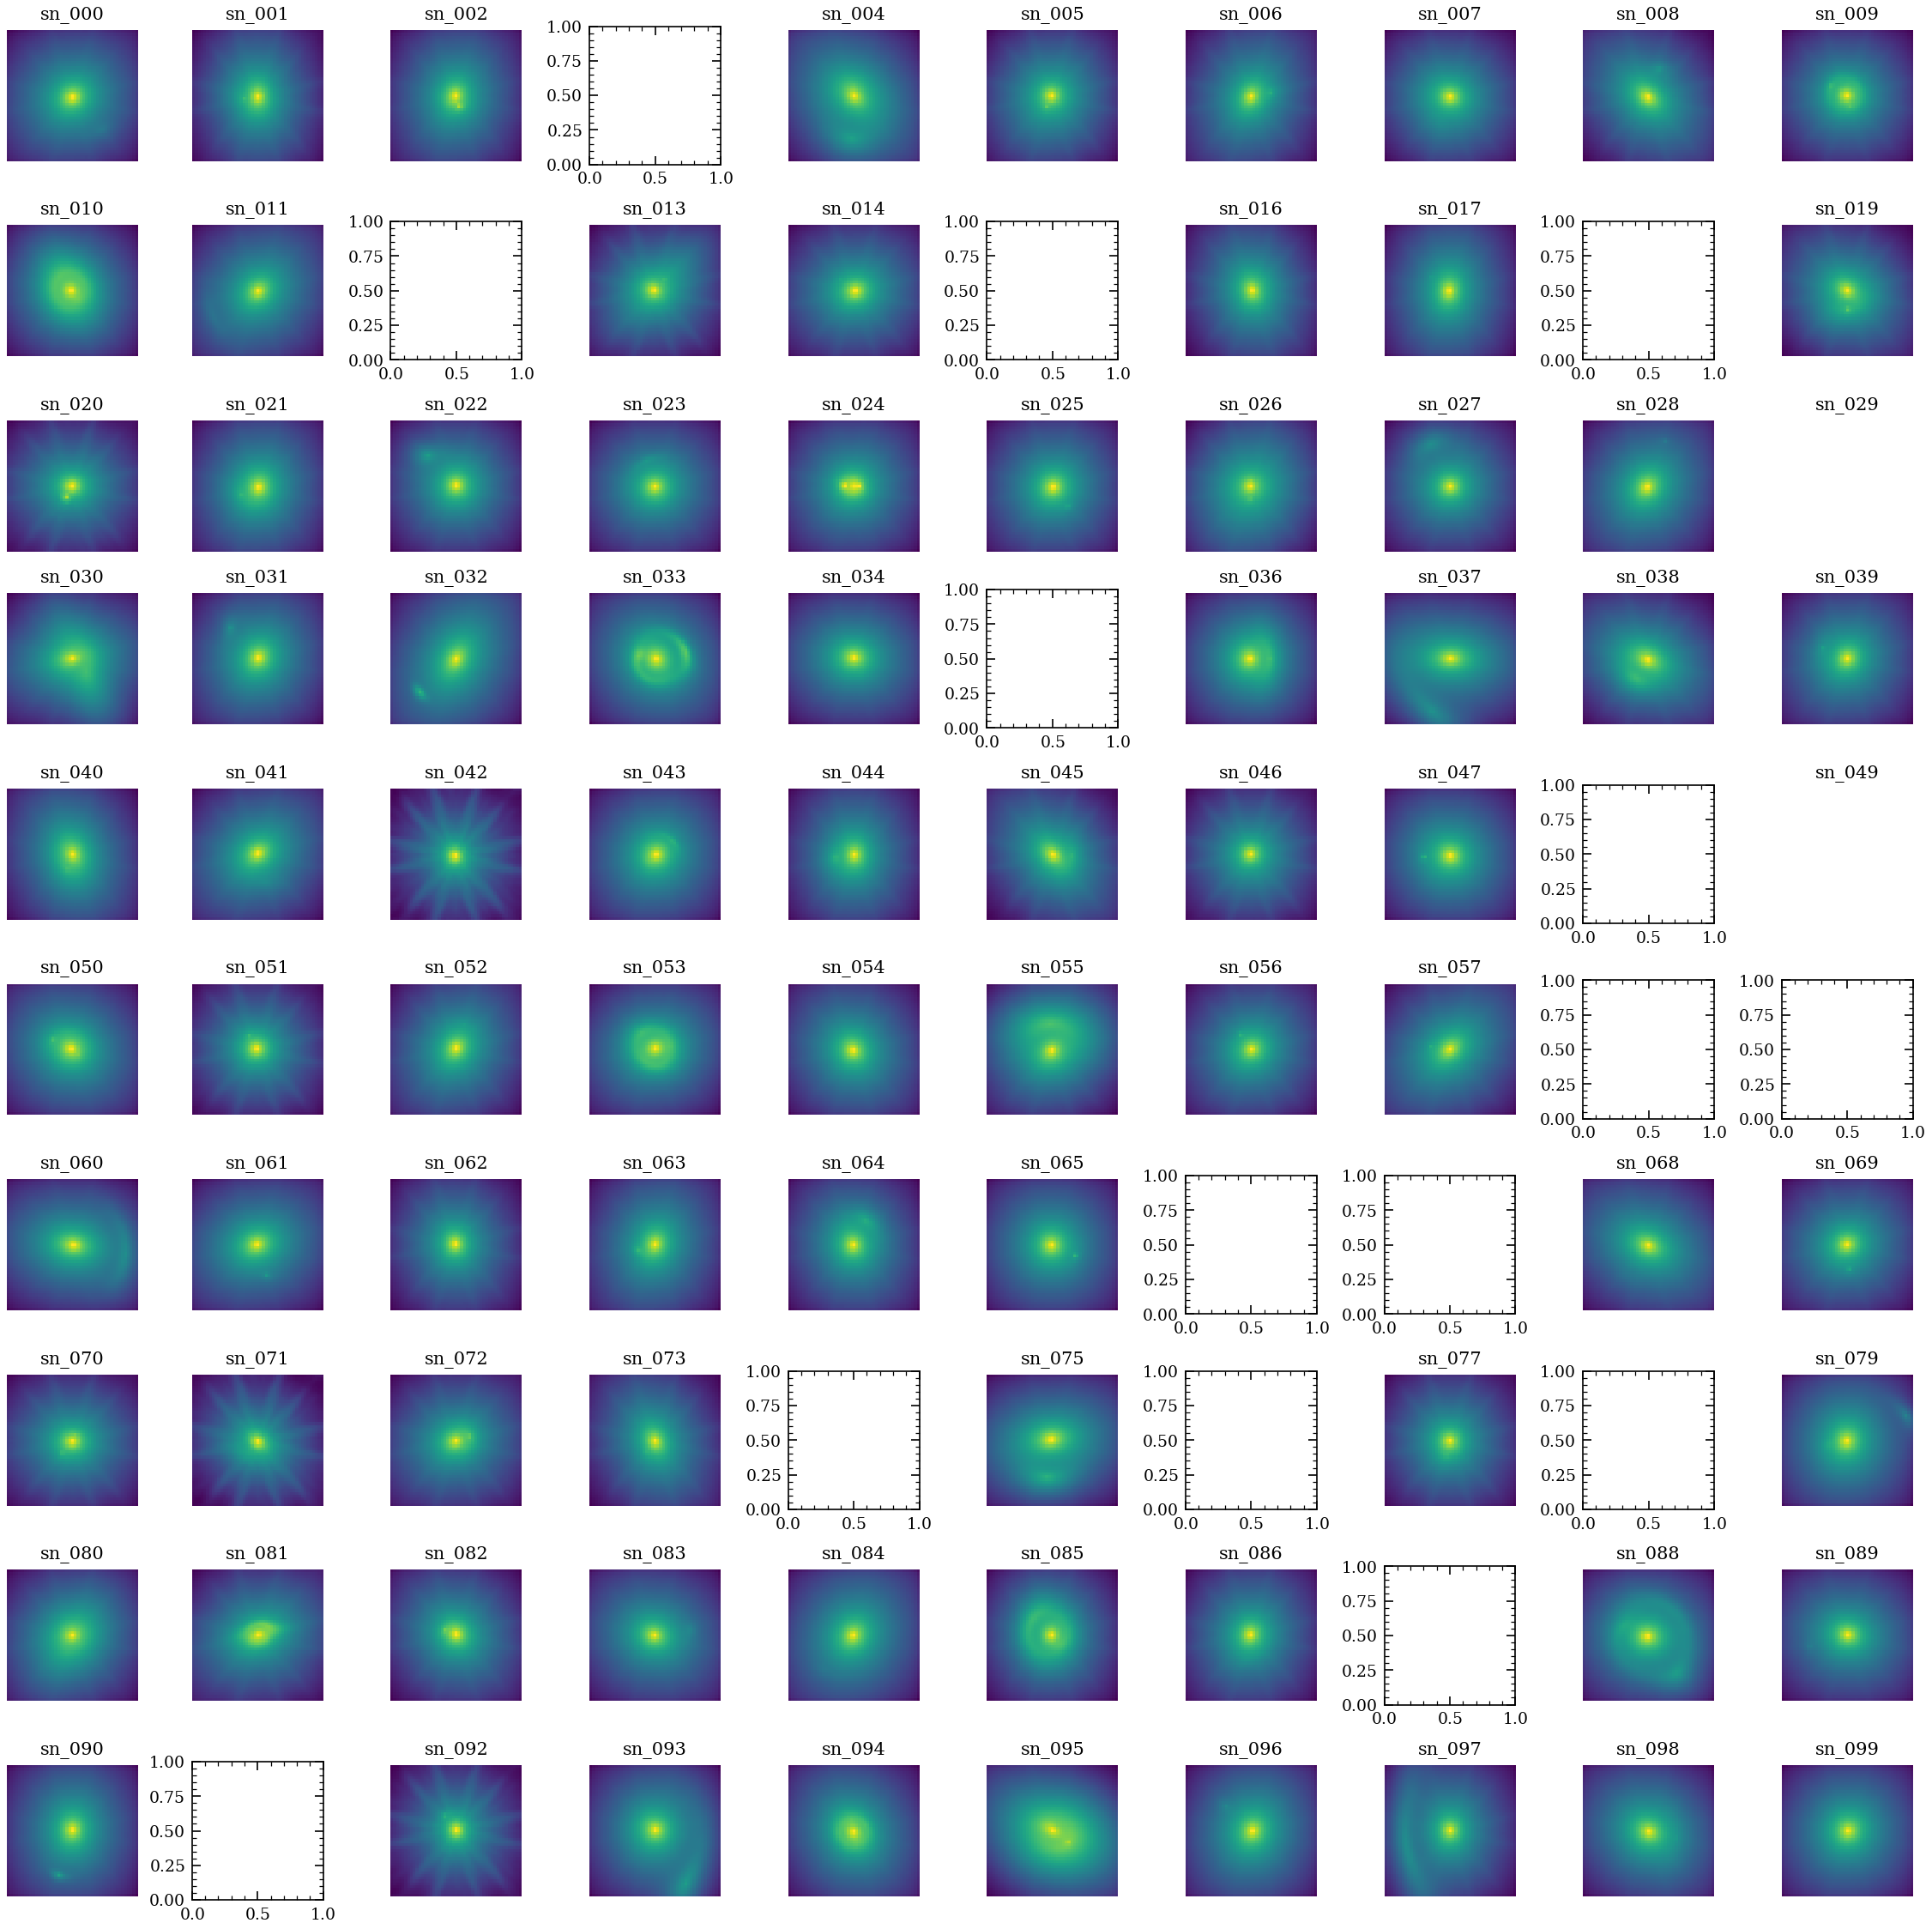

In [31]:
_, ax = plt.subplots(10, 10, figsize=(15, 15), constrained_layout=True)

for i in range(100):
    sample = lens_population[i]
    try:
        sn_to_plot = LensedSupernova.from_slsim(sample, name=f'sn_{str(i).zfill(3)}')
    except Exception as e:
        print(f"Error occurred while processing sample {i}: {e}")
        continue
    synth_to_plot = SyntheticImage(sn_to_plot, roman, 'F129', pieces=True, kwargs_psf=kwargs_psf)
    ax[i//10, i%10].imshow(synth_to_plot.data, norm=LogNorm())
    ax[i//10, i%10].set_title(f'sn_{str(i).zfill(3)}')
    ax[i//10, i%10].axis('off')

plt.show()

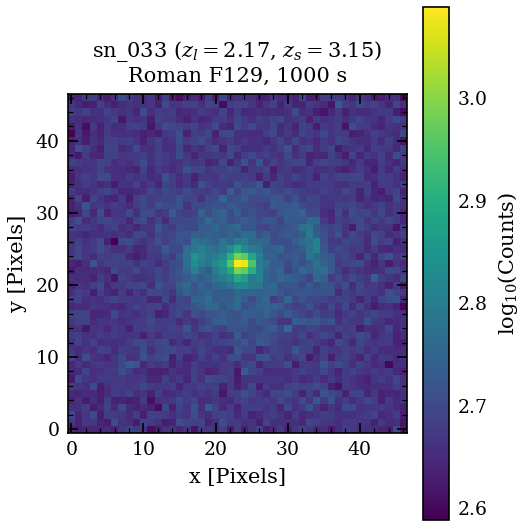

In [32]:
exposure = Exposure(synth, 1000)
exposure.plot()

In [33]:
sn_with = deepcopy(sn)
sn_with.quick_add()

sn_none = deepcopy(sn)

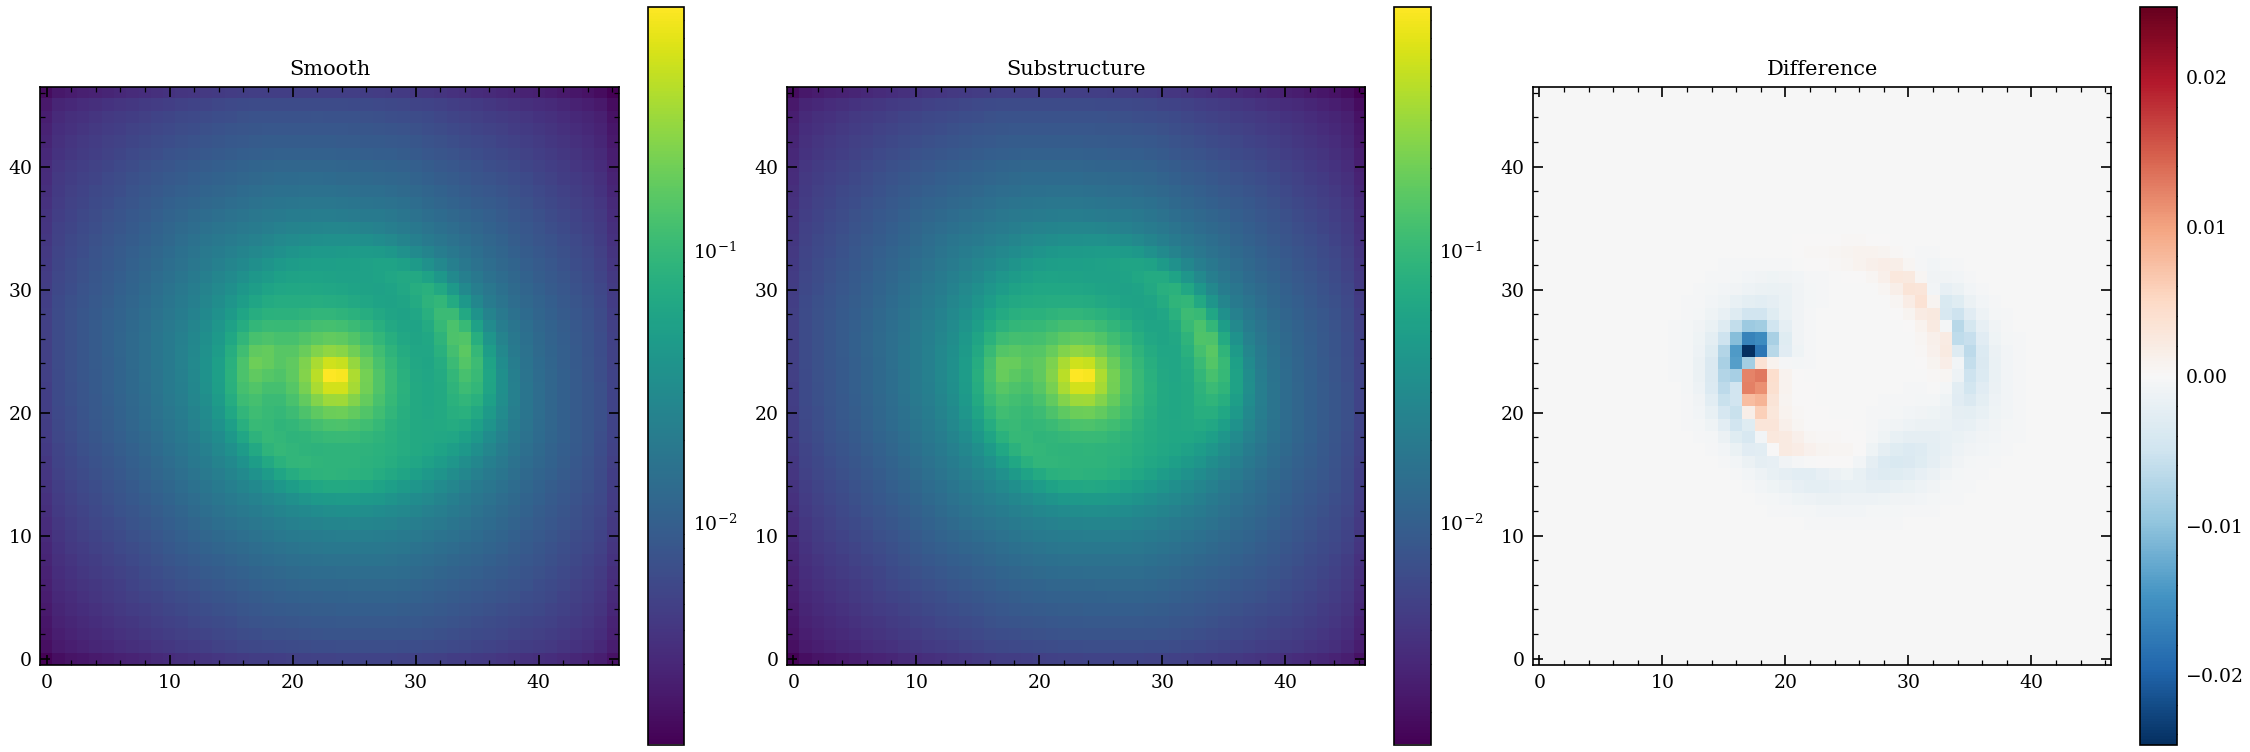

In [34]:
synth_none = SyntheticImage(sn_none, roman, 'F129', kwargs_psf=kwargs_psf)
synth_with = SyntheticImage(sn_with, roman, 'F129', kwargs_psf=kwargs_psf)

_, ax = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)
im0 = ax[0].imshow(synth_none.data, norm=LogNorm())
ax[0].set_title('Smooth')
plt.colorbar(im0, ax=ax[0])
im1 = ax[1].imshow(synth_with.data, norm=LogNorm())
ax[1].set_title('Substructure')
plt.colorbar(im1, ax=ax[1])
im2 = ax[2].imshow(synth_with.data - synth_none.data, norm=CenteredNorm(), cmap='RdBu_r')
ax[2].set_title('Difference')
plt.colorbar(im2, ax=ax[2])
plt.show()

In [35]:
# synth_with.overplot_subhalos()

In [36]:
import numpy as np
from tqdm import tqdm

sample_times = np.array([-25, 0, 50, 75])

synths_with, exposures_with, synths_none, exposures_none = [], [], [], []

sn_with = deepcopy(sn)
sn_with.quick_add()
sn_none = deepcopy(sn)

for t in tqdm(sample_times):
    # set observation times
    sn_with.set_observation_time(t, 'F129')
    sn_none.set_observation_time(t, 'F129')

    # ray-shoot
    synth_with = SyntheticImage(sn_with, roman, 'F129', kwargs_psf=kwargs_psf)
    synth_none = SyntheticImage(sn_none, roman, 'F129', kwargs_psf=kwargs_psf)
    synths_with.append(synth_with)
    synths_none.append(synth_none)

    exposure_with = Exposure(synth_with, 1000)
    poisson_noise = exposure_with.poisson_noise
    reciprocity_failure = exposure_with.reciprocity_failure
    dark_noise = exposure_with.dark_noise
    nonlinearity = exposure_with.nonlinearity
    ipc = exposure_with.ipc
    read_noise = exposure_with.read_noise
    engine_params = {
        'poisson_noise': poisson_noise,
        'reciprocity_failure': reciprocity_failure,
        'dark_noise': dark_noise,
        'nonlinearity': nonlinearity,
        'ipc': ipc,
        'read_noise': read_noise
    }

    exposure_none = Exposure(synth_none, 1000, 
    # engine_params=engine_params
    )

    exposures_with.append(exposure_with)
    exposures_none.append(exposure_none)

100%|██████████| 4/4 [09:26<00:00, 141.60s/it]


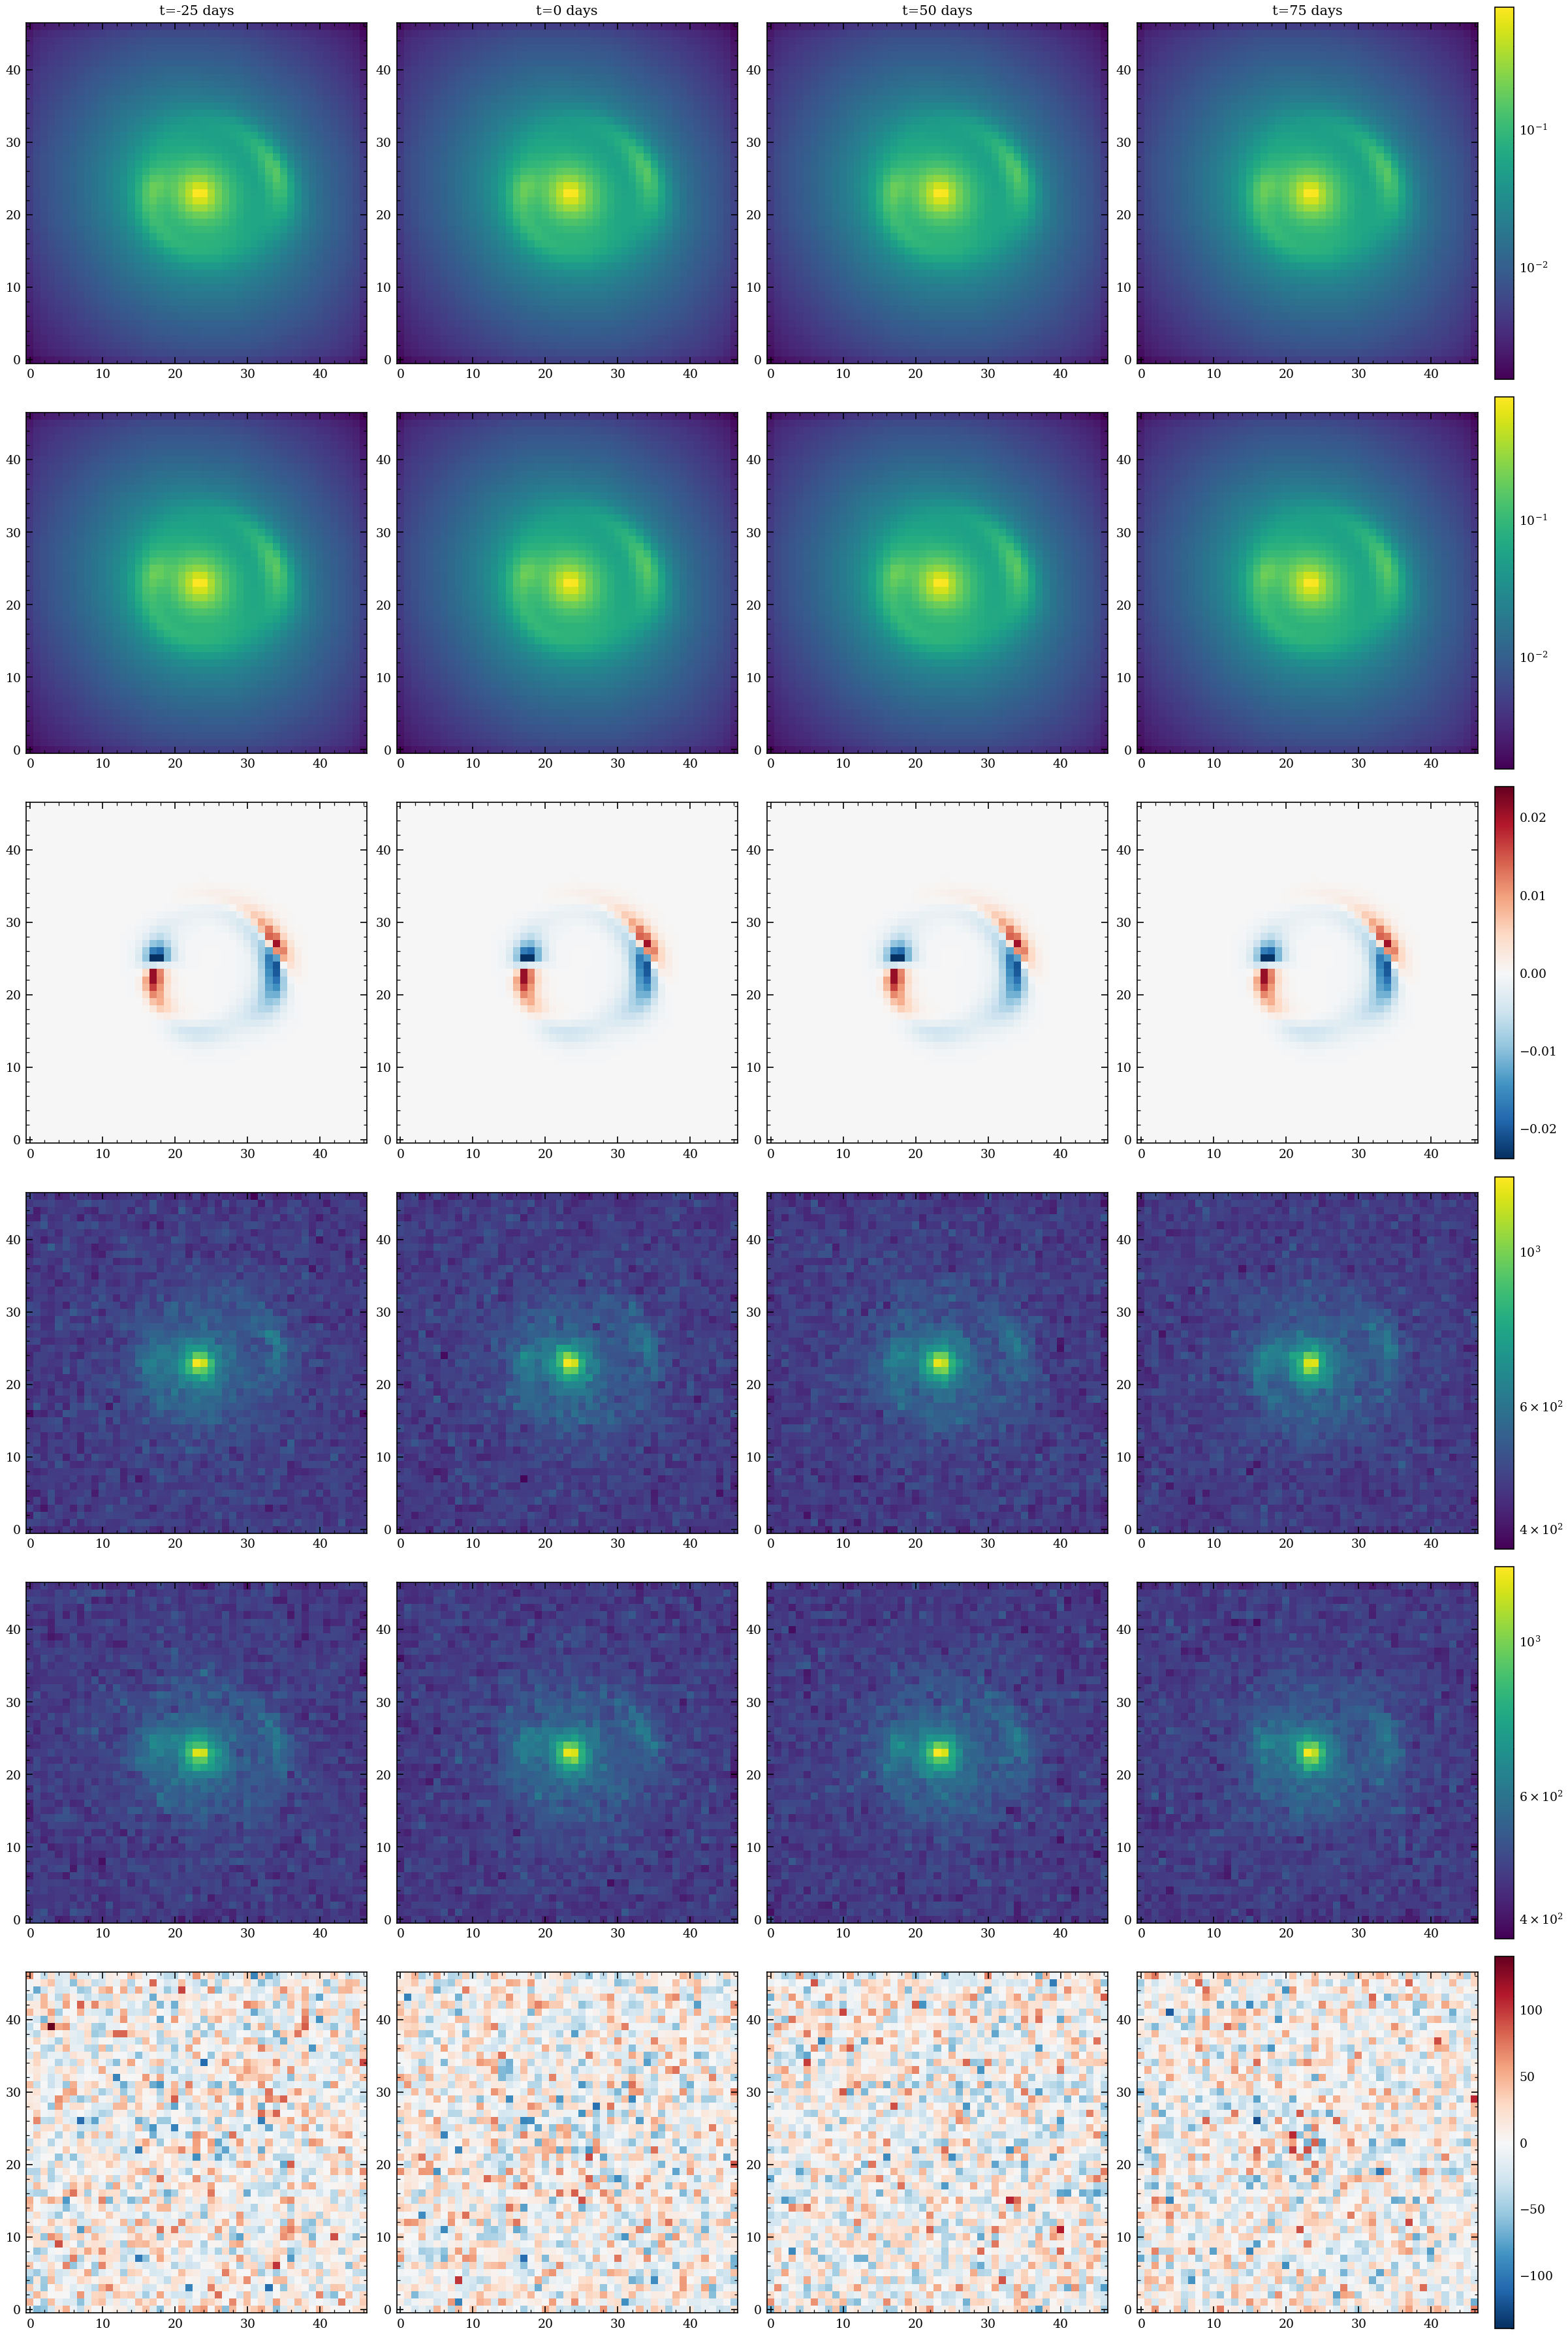

In [37]:
fig, ax = plt.subplots(6, 4, figsize=(16, 24), constrained_layout=True)

# shared color scale for rows 0 and 1 (synthetic images)
all_signal = np.concatenate([synths_with[i].data.ravel() for i in range(len(sample_times))] +
                             [synths_none[i].data.ravel() for i in range(len(sample_times))])
signal_norm = LogNorm(vmin=np.nanmin(all_signal[all_signal > 0]), vmax=np.nanmax(all_signal))

# shared color scale for row 2 (synthetic image differences)
all_diff = np.concatenate([(synths_with[i].data - synths_none[i].data).ravel() for i in range(len(sample_times))])
diff_norm = CenteredNorm(vcenter=0, halfrange=np.nanmax(np.abs(all_diff)))

# shared color scale for rows 3 and 4 (exposures)
all_exp = np.concatenate([exposures_with[i].data.ravel() for i in range(len(sample_times))] +
                          [exposures_none[i].data.ravel() for i in range(len(sample_times))])
exp_norm = LogNorm(vmin=np.nanmin(all_exp[all_exp > 0]), vmax=np.nanmax(all_exp))

# shared color scale for row 5 (exposure differences)
all_exp_diff = np.concatenate([(exposures_with[i].data - exposures_none[i].data).ravel() for i in range(len(sample_times))])
exp_diff_norm = CenteredNorm(vcenter=0, halfrange=np.nanmax(np.abs(all_exp_diff)))

for i, t in enumerate(sample_times):
    im0 = ax[0, i].imshow(synths_with[i].data, norm=signal_norm)
    ax[0, i].set_title(f't={t} days')
    im1 = ax[1, i].imshow(synths_none[i].data, norm=signal_norm)
    im2 = ax[2, i].imshow(synths_with[i].data - synths_none[i].data, norm=diff_norm, cmap='RdBu_r')

    im3 = ax[3, i].imshow(exposures_with[i].data, norm=exp_norm)
    im4 = ax[4, i].imshow(exposures_none[i].data, norm=exp_norm)
    im5 = ax[5, i].imshow(exposures_with[i].data - exposures_none[i].data, norm=exp_diff_norm, cmap='RdBu_r')

fig.colorbar(im0, ax=ax[0, -1])
fig.colorbar(im1, ax=ax[1, -1])
fig.colorbar(im2, ax=ax[2, -1])
fig.colorbar(im3, ax=ax[3, -1])
fig.colorbar(im4, ax=ax[4, -1])
fig.colorbar(im5, ax=ax[5, -1])

plt.show()

In [ ]:
lc = sn.get_light_curve('F129')

plt.plot(lc['time'], lc['magnitudes'][0], label='Image 1')
plt.plot(lc['time'], lc['magnitudes'][1], label='Image 2')
plt.gca().invert_yaxis()
plt.xlabel('Time [days]')
plt.ylabel('F129 Magnitude')
plt.legend()
plt.show()